# Pingviinide analüüs

## Impordid ja seadistused

In [ ]:
import pandas as pd
import duckdb

import matplotlib.pyplot as plt
import seaborn as sns

## Andmete laadimine

In [2]:
penguins = sns.load_dataset("penguins")
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [ ]:
# Andmetest ülevaate saamiseks. Näit palju on tühje väärtuseid (null_percentage).
# Puuduvate väärtuste puhul: 1) teha mitte midagi, 2) visata välja read, kus on puuduvad väärtused 3) visata välja tulp, kus on puuduvad väärtused, 4) asendada puuduvad väärtused - kas 0-ga, valimi keskmisega
duckdb.sql("""SUMMARIZE penguins""").df

<bound method pybind11_detail_function_record_v1_system_libcpp_abi1.df of ┌───────────────────┬─────────────┬─────────┬───────────┬───────────────┬────────────────────┬────────────────────┬────────────┬────────────────────┬────────────┬───────┬─────────────────┐
│    column_name    │ column_type │   min   │    max    │ approx_unique │        avg         │        std         │    q25     │        q50         │    q75     │ count │ null_percentage │
│      varchar      │   varchar   │ varchar │  varchar  │     int64     │      varchar       │      varchar       │  varchar   │      varchar       │  varchar   │ int64 │  decimal(9,2)   │
├───────────────────┼─────────────┼─────────┼───────────┼───────────────┼────────────────────┼────────────────────┼────────────┼────────────────────┼────────────┼───────┼─────────────────┤
│ species           │ VARCHAR     │ Adelie  │ Gentoo    │             3 │ NULL               │ NULL               │ NULL       │ NULL               │ NULL       │   344 │

In [ ]:
# Eemaldame tühjad read
penguins_not_null = penguins.dropna()
penguins_not_null

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [ ]:
# palju on igas liigis isendeid
duckdb.sql("""
    SELECT
        species, 
        count(*) AS count
    FROM penguins_not_null
    GROUP BY species
""").df()

,species,count
0,Adelie,146
1,Chinstrap,68
2,Gentoo,119


In [9]:
# palju on emaseid ja isaseid
duckdb.sql("""
    SELECT
        sex, 
        count(*) AS count
    FROM penguins_not_null
    GROUP BY sex
""").df()

,sex,count
0,Male,168
1,Female,165


In [49]:
# palju on erinevaid liike ühel saarel
duckdb.sql("""
    SELECT
        island, 
        species,
        count(distinct species) AS count
    FROM penguins_not_null
    GROUP BY island, species
""").df()

,island,species,count
0,Dream,Adelie,1
1,Dream,Chinstrap,1
2,Biscoe,Adelie,1
3,Torgersen,Adelie,1
4,Biscoe,Gentoo,1


In [50]:
# palju on erinevaid liike ühel saarel
duckdb.sql("""
    SELECT
        island,
        count(*) AS count
    FROM penguins_not_null
    GROUP BY island
""").df()

,island,count
0,Torgersen,47
1,Dream,123
2,Biscoe,163


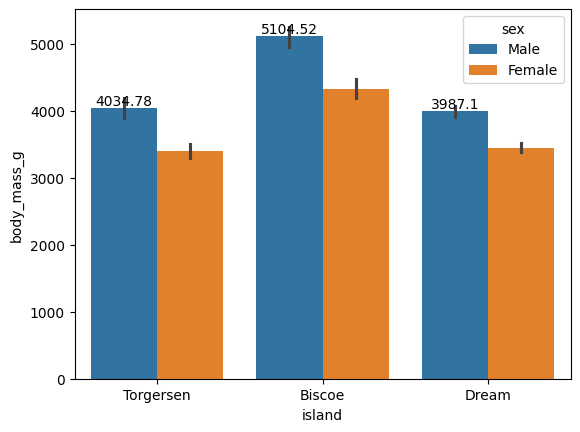

In [14]:
ax = sns.barplot(penguins_not_null, x="island", y="body_mass_g", hue="sex")
# Lisa graafikule 
ax.bar_label(ax.containers[0], fontsize=10);

<Axes: xlabel='body_mass_g', ylabel='species'>

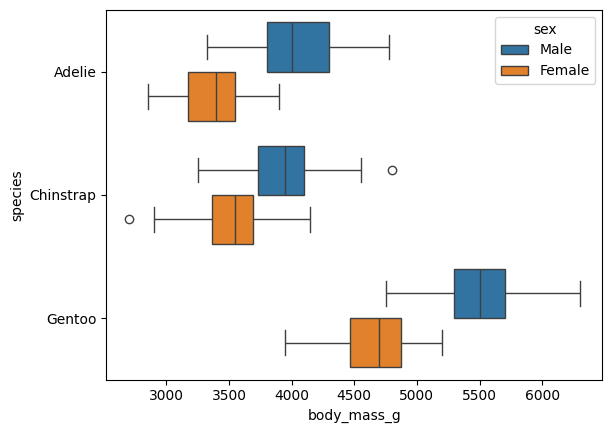

In [51]:
sns.boxplot(penguins_not_null, x="body_mass_g", y="species", hue="sex")

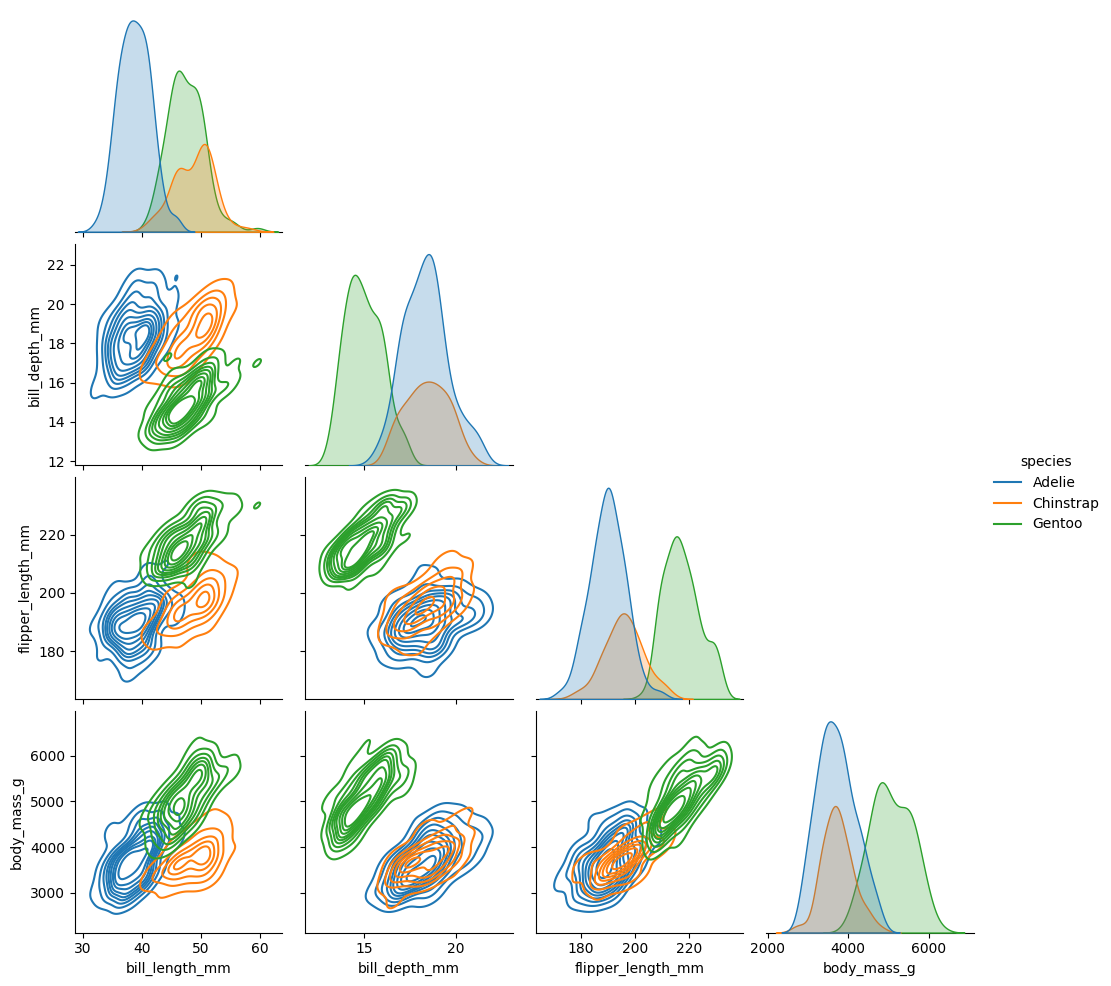

In [22]:
sns.pairplot(penguins, hue="species", kind="kde", corner=True)

<Axes: xlabel='flipper_length_mm', ylabel='Density'>

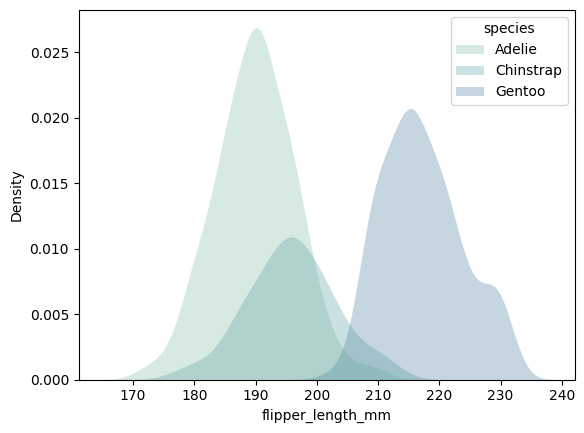

In [37]:
# kdeplot - kaalu jaotus
sns.kdeplot(
    penguins,
    x="flipper_length_mm",
    hue = "species",
    fill=True,
    palette="crest",
    linewidth=0
)

<Axes: xlabel='flipper_length_mm', ylabel='body_mass_g'>

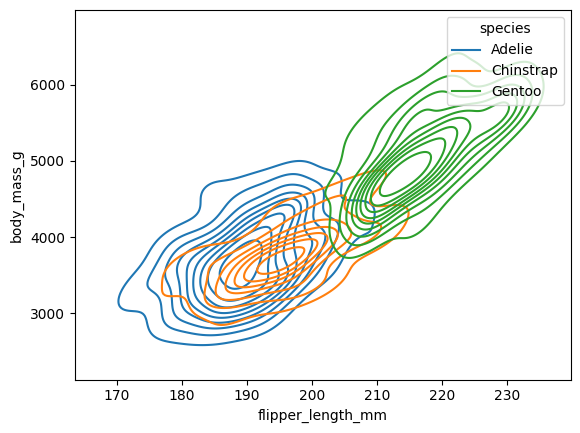

In [56]:
sns.kdeplot(
    penguins,
    x="flipper_length_mm",
    y="body_mass_g",
    hue = "species"
)

<Axes: ylabel='species'>

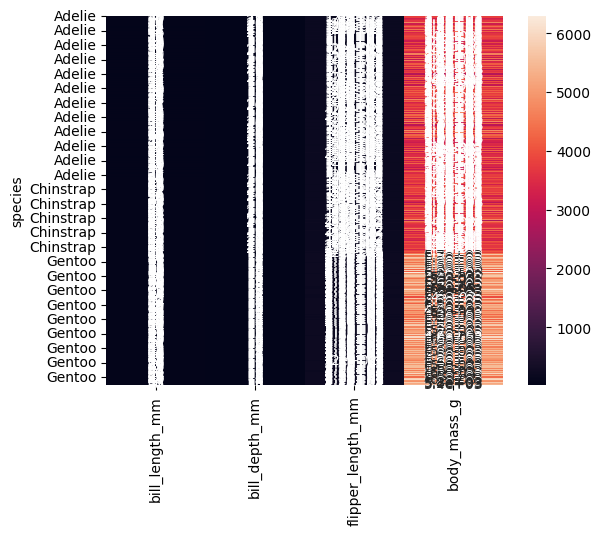

In [57]:
sns.heatmap(
    penguins_not_null[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g", "species"]].set_index("species"),
    annot=True
)

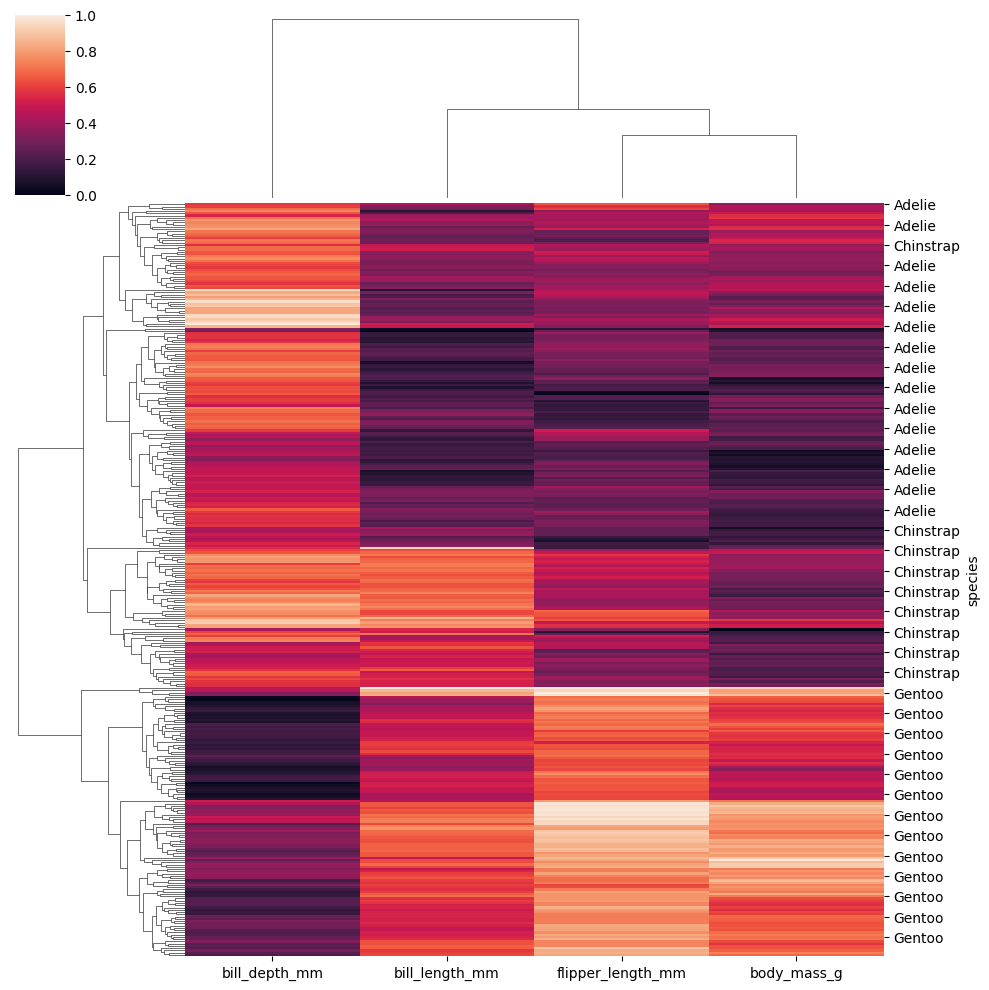

In [62]:
sns.clustermap(
    penguins_not_null[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g", "species"]].set_index("species")
    ,standard_scale=1
    ,figsize=(10,10)
)

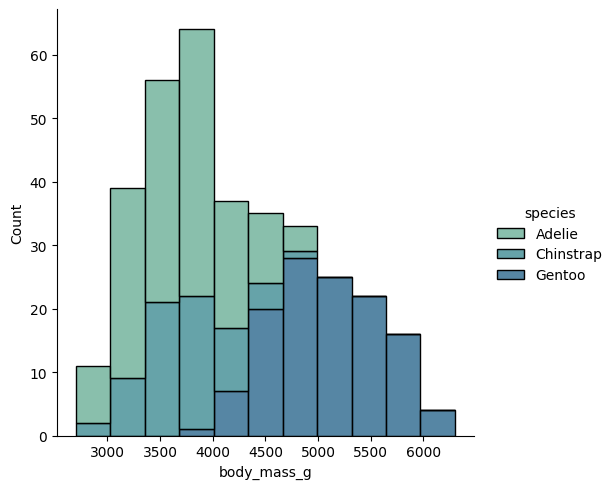

In [47]:
sns.displot(penguins, x="body_mass_g", hue="species", multiple="stack", palette="crest",)

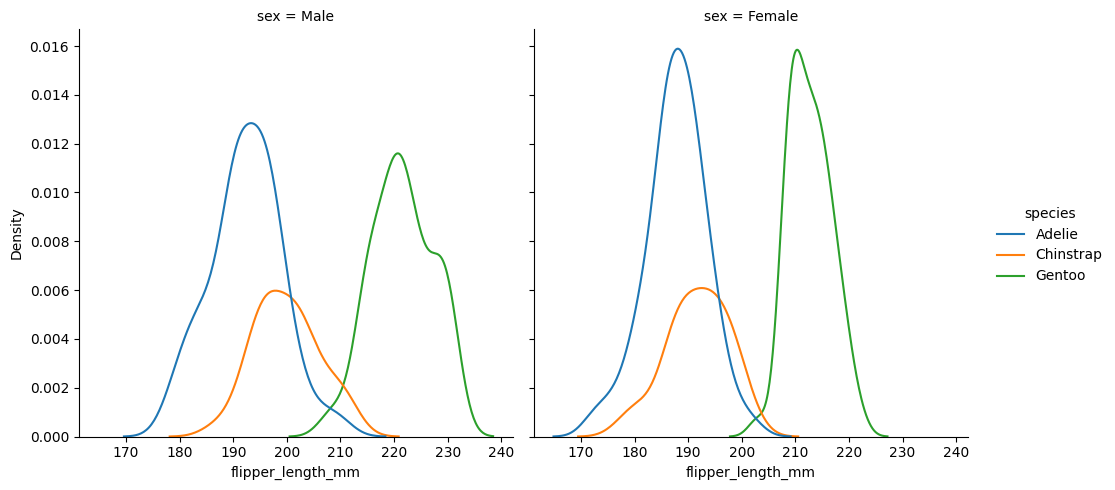

In [45]:
sns.displot(data=penguins, x="flipper_length_mm", hue="species", col="sex", kind="kde")